# 1. MODELO DE CLASIFICACION CON NAIVE BAYES

### 1-Importar los datos


In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive') ##estas dos lineas son para conectar colab con drive
##Aca destinamos la raiz del sistema de archivos
raiz='/content/drive/MyDrive/ANALITICA'## para jalar la base de datos tenemos que decirle en que parte del archivo está, pongo el nombre de la carpeta al final

#IMPORTO EL ARCHIVO
solicitantes = pd.read_excel(raiz + '/0. SolicitantesCrédito (1).xlsx') ##llamamamos a la base de datos solicitantes #la equis de la izquierda es el inspector de variables

#ctrl+shift+enter se ejecuta la porcion del codigo que este selccionando

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
solicitantes.head() ##comando head trae 5 primeros, si pongo un numero entre parentesis, me sale esa cantidad, phyton empieza a contar desde cero


,Unnamed: 0,Edad,Sexo,Estado civil,Hijos,Perscargo,Estrato,Nivel de estudios,Tipo de contrato,Ingresos,...,Plazo,Cuota (COP),ConoCliente,Garantia,RespPat,MoraCome,PreApr,Prob.Default (PD),Score,LGD
0,1,38,NR,Casado,1,0,3,Bachiller,Ninguno,5424576,...,48,82691.506204,Buenas Referencias,Sin Codeudor,Sin Patrimonio,Con Experiencia sin Mora,1.0,0.041659,582.478943,0.063702
1,2,51,NR,Separado,6,1,4,Técnico,Ninguno,1144064,...,36,22781.212598,Buenas Referencias,Sin Codeudor,Prop.sin Hipoteca,Con Experiencia sin Mora,1.0,0.234951,479.839966,0.465636
2,3,37,Mujer,Casado,2,0,3,Tecnólogo,Indefinido,2069853,...,36,46294.596244,Buenas Referencias,Con Codeudor(es),Sin Patrimonio,Con Experiencia sin Mora,0.0,0.170330,417.653107,0.290071
3,4,29,NR,Separado,1,0,2,Tecnólogo,Ninguno,1893080,...,24,69564.950015,Buenas Referencias,Con Codeudor(es),Sin Patrimonio,Con Experiencia sin Mora,1.0,0.201659,316.791107,0.278389
4,5,42,Mujer,Casado,3,4,2,Especializacion,Ninguno,3000367,...,24,112478.307883,Buenas Referencias,Con Codeudor(es),Sin Patrimonio,Con Experiencia sin Mora,1.0,0.140929,441.809570,0.203359


In [ ]:
solicitantes.tail() ##muestra los ultimos del dataset

,Unnamed: 0,Edad,Sexo,Estado civil,Hijos,Perscargo,Estrato,Nivel de estudios,Tipo de contrato,Ingresos,...,Plazo,Cuota (COP),ConoCliente,Garantia,RespPat,MoraCome,PreApr,Prob.Default (PD),Score,LGD
8373,8374,31,Hombre,Soltero,2,0,5,Bachiller,Indefinido,5891088,...,48,115108.056436,Buena Experiencia CFB,Sin Codeudor,Sin Patrimonio,Con Experiencia sin Mora,1.0,0.035120,659.471375,0.066962
8374,8375,38,Hombre,Separado,0,0,3,Bachiller,Labor Contratada,3092079,...,36,96789.562091,Buenas Referencias,Sin Codeudor,Prop.sin Hipoteca,Con Experiencia sin Mora,1.0,0.101976,465.011536,0.165936
8375,8376,43,Mujer,Casado,1,2,2,Tecnólogo,Ninguno,2542007,...,36,49713.608249,Buenas Referencias,Sin Codeudor,Sin Patrimonio,Con Experiencia sin Mora,1.0,0.156707,423.237305,0.247763
8376,8377,37,Mujer,Casado,1,2,3,Tecnólogo,Indefinido,5677067,...,36,163602.818587,Buenas Referencias,Con Codeudor(es),Sin Patrimonio,Con Experiencia sin Mora,1.0,0.037719,592.670837,0.051356
8377,8378,24,NR,Soltero,0,0,2,Tecnólogo,Indefinido,1950392,...,36,69024.928055,Buenas Referencias,Sin Codeudor,Sin Patrimonio,Con Experiencia sin Mora,NaN,NaN,NaN,NaN


In [ ]:
solicitantes.info() ##me dice como se llama la columna, non null count a veces hay campos que estan incompletos, hay que tratar de hacer que el 5842, se convierta en 8378

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               8378 non-null   int64  
 1   Edad                     8378 non-null   int64  
 2   Sexo                     8378 non-null   object 
 3   Estado civil             8378 non-null   object 
 4   Hijos                    8378 non-null   int64  
 5   Perscargo                8378 non-null   int64  
 6   Estrato                  8378 non-null   int64  
 7   Nivel de estudios        8378 non-null   object 
 8   Tipo de contrato         8378 non-null   object 
 9   Ingresos                 8378 non-null   int64  
 10  Egresos                  8378 non-null   int64  
 11  Tipo de actividad        8378 non-null   object 
 12  Tipo de vivienda         8378 non-null   object 
 13  Total Activos            8378 non-null   float64
 14  Total pasivos           

##2- Limpieza de los datos

In [ ]:
solicitantes.shape ##me dice dimensionalidad (cuantas filas y cuantas columnas)

(8378, 35)

In [ ]:
##vamos a filtrar a los 5mil a los que ya se les evaluó si se les preaprobaron o no
##elimino las filas donde preap esta vacio
##vamos a crear una nueva variable y guardar los solicitantes de credito a los que ya se les ha informado si se les niega o se les aprueba
#X= Variable independiente, (como las x tienen incidencia sobre yd) Yd=Preaprobacion
XD=solicitantes.dropna(subset=['PreApr']) #dropna elimina los n/a (campos vacios), solo queremos que borre los registros con vacios en columna de preaprobados, para eso sirve subset



In [ ]:
XD.shape ##se borraron los registros donde el preaprobado no ha sido determinado

(5842, 35)

In [ ]:
##vamos a eliminar las columnas que no nos sirven
XD=XD [['Edad','Ingresos','Egresos','Monto (EAD)', 'Hijos', 'Estrato', 'Perscargo', 'Cuota (COP)', 'Plazo']] #Primero se ejecuta y luego para verlos seleccion xd y oprimo ctrl+shift+enter
#Aqui ya tenemos limpio el dataset
#hay que crear un dataset de una sola columna que contenga los Yd (preaprobados)

In [ ]:
#Escojo la variable dependiente del modelo, preap, que no se encuentra en xd
yd=solicitantes['PreApr'].dropna()#va a ir a la base de datos de solicitantes y me a traer la columna, necesitamos que yd tenga la misma dimensionalidad que xd, entonces usamos dropna
##con un solo corchete para convertirlo facilmente a un arreglo, para entrenar el modelo
##ya queda con 5842 registros

In [ ]:
yd.shape

(5842,)

### 3-Implementar modelo de NaiveBayes

In [ ]:
##librerias=conjunto de funciones que pueden existir previante en phyton por defecto o que se pueden descargar y que permiten ampliar las funcionalidades de phyton
##importamos las librerias necesarias
import numpy as np ##libreria numerica para construir arreglos de datos, operar matrices
import pandas as pd ##pandas con numpy
import matplotlib.pyplot as plt##para graficos

from sklearn.naive_bayes import GaussianNB


In [ ]:
##Convierto los datasets a arrays (arreglos)
XDArray= np.array (XD, dtype=float)#le voy a decir a numpy que convierta la dataset (XD) en un arreglo para que lo entienda el modelo gaussiano
#Coversion de tipos, que todos los datos sean iguales (dtype) float son decimales
ydArray=np.array(yd, dtype=float)# los convirtio en matrices y vectores para que naive bayes los pueda usar

In [ ]:
#ENTRENAR EL MODELO
modelNB = GaussianNB() #Estoy metiendo el esqueleto del modelo que trae la libreria en una variable para poder entrenarla
modelNB.fit(XDArray, ydArray)#lo mas importante, parametro fit le dice que aprenda, recibiendo los x y los y, estoy trayendo el disño por defecto que traigo de la libreria, ingreso x y y y la relacion que existe entre ellas para que apruebe o rechace el credito

GaussianNB()

In [ ]:
##AHORA VAMOS A PROBAR QUE TAN BIEN APRENDIO EL MODELO
# Predigo los yd
ydPred=modelNB.predict(XDArray)#verctor nuevo
##XD(edad,ingresos, egresos,monto)Yd(Preaprobado), vuelvo a colocar los x y me va agenerar un Yd pred,
##vamos a crear yd de generalizacion, pasan 3 fases, 1-train, dar yd y xd, 2-test, validacion, luego de que el modelo esta entrenado vuelvo a meter los datos observados para ver si los valores coinciden
##3- generalizacion, donde meto datos nuevos
##Arreglos son matrices
ydPred ##crea un verctor de 0s y 1s


array([1., 0., 0., ..., 0., 0., 1.])

## 4. Matriz de confusion

In [ ]:
##importamos herramientas de una libreria
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
##guardamos matriz en variable cm
cm=confusion_matrix(ydArray, ydPred)
cm
##matriz de confusion tiene 4 cuadrantes, primero verdaderos negativos, segundo false positive el modelo los predijo como positivo pero no es
##tercero false negative dijo que falso pero era verdadero, cuarto dijo que era verdadero y era verdadero
##matriz de confusion para booleanos (binarios)

array([[2539,  420],
       [1041, 1842]])

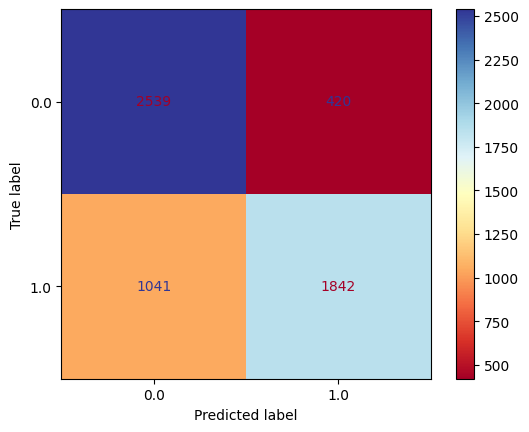

In [ ]:
disp = ConfusionMatrixDisplay (confusion_matrix=cm, display_labels=modelNB.classes_)
disp.plot(cmap='RdYlBu')##para crear el grafico
plt.show() ##para mostrarlo

##5. Construir metricas de exactitud del modelo

In [ ]:
##Exactitud (Accuracy)
## Numero de predicciones correctas sobre numero total de predicciones
##traemos 1945 de cm (true positive)
exactitud= (cm[1][1]+ cm[0][0])/cm.sum()
print(f'La exactitud (accuracy) del modelo es de {exactitud:.2%}')

##La exactitud con 4 variables era del 76.14% y al aumentar el numero de variables disminuyó,
## lo que quiere decir que empeoró la capacidad del modelo de acertar en sus predicciones correctas sobre el total de datos.
## De igual forma el hecho de que el modelo prediga correctamente el 74.99% de los casos sigue siendo un buen porcentaje.

La exactitud (accuracy) del modelo es de 74.99%


In [ ]:
##TASA DE ERROR
## Numero de predicciones incorrectas sobre el total de predicciones
##opcion 1
error=(cm[1][0]+ cm[0][1])/cm.sum()
##opcion 2
error=1-exactitud
print(f'El error del modelo es de {error:.2%}')
## En el caso de la tasa de error, el porcentaje de casos aprobados y preaprobados de manera incorrecta por el modelo fue del 25%
## es decir, este aumentó respecto al 23.86% obtenido cuando se tomó la metrica con 4 variables. Con esto tambien se puede observar que las metricas de exactitud
## y tasa de error aumentaron y disminuyeron respectivamente en la misma proporcion (son inversamente proporcionales)

El error del modelo es de 25.01%


In [ ]:
##PRECISION
#Que tan cerca esta un resultado del valor verdadero, de los que calcula verdaderos cuales son efectivamente verdaderos
precision= cm[1][1]/(cm[1][1]+cm[0][1])
print(f'La precision del modelo es de {precision:.2%}')
## La precision con 4 variables era del 81.01% y al aumentar el numero de variables subió ligeramente a 81.43%,
##lo que quiere decir que aumentó su capacidad de acertar los valores verdaderos. Ademas podemos concluir que el modelo es relativamente  eficiente, pues será
## capaz de predecir acertadamente el 81.43% de aprobados

La precision del modelo es de 81.43%


In [ ]:
## SENSIBILIDAD (RECALL)
##Es la cantidad de positivos bien clasificados respecto al total de positivos
sensibilidad= cm[1][1]/(cm[1][1]+cm[1][0])
print(f'La sensibilidad del modelo es de {sensibilidad:.2%}')
## La sensibilidad con 4 variables era del 67.46% y al aumentar el numero de variables disminuyó a 63.89%
## lo que quiere decir que desmejoró la capacidad del modelo de identificar correctamente todas las instancias positivas (solicitantes aprobados).
## El modelo abarca correctamente el 63.89% de aprobados, lo cual sigue siendo relativamente alto por lo que funciona bien.

La sensibilidad del modelo es de 63.89%


In [ ]:
(cm[1][1]+cm[1][0])

2883

In [ ]:
##ESPECIFICIDAD
##Es la cantidad de negativos bien clasificados por el modelo respecto al total de negativos
especificidad= cm[0][0]/(cm[0][1]+cm[0][0])
print(f'La especificidad del modelo es de {especificidad:.2%}')
##El modelo es capaz de identificar correctamente el 85.81% de todos los solicitantes que no deberian ser aprobados, lo cual es suficientemente alto para afirmar
#que el modelo funciona bien en este aspecto


La especificidad del modelo es de 85.81%


## 6. Pronostico de la Preaprobacion para solicitantes nuevos


In [ ]:
##filtro los solicitantes que no tienen valor en PreApr
XDGener=solicitantes[solicitantes['PreApr'].isna()]##isna valida valores vacios, si encuentra 1 o 0 me dice falso, si no encuentra nada true
XDGener.head()

,Unnamed: 0,Edad,Sexo,Estado civil,Hijos,Perscargo,Estrato,Nivel de estudios,Tipo de contrato,Ingresos,...,Plazo,Cuota (COP),ConoCliente,Garantia,RespPat,MoraCome,PreApr,Prob.Default (PD),Score,LGD
6,7,38,NR,Soltero,3,0,3,Profesional,Indefinido,1534711,...,60,2.009414e+04,Buenas Referencias,Sin Codeudor,Sin Patrimonio,Con Experiencia sin Mora,NaN,NaN,NaN,NaN
7,8,47,Mujer,Casado,0,0,2,Profesional,Ninguno,136750,...,48,3.563229e+03,Buena Experiencia CFB,Sin Codeudor,Sin Patrimonio,Con Experiencia sin Mora,NaN,NaN,NaN,NaN
11,12,46,Mujer,Casado,0,1,4,Primaria,Indefinido,7097220,...,3,1.090054e+06,Buenas Referencias,Con Codeudor(es),Prop.sin Hipoteca,Con Experiencia sin Mora,NaN,NaN,NaN,NaN
13,14,37,Mujer,Soltero,4,2,2,Técnico,Ninguno,1791987,...,48,6.856249e+04,Buena Experiencia CFB,Sin Codeudor,Prop.sin Hipoteca,Mora mayor a 60 Dìas,NaN,NaN,NaN,NaN
16,17,22,NR,Unión Libre,1,0,2,Bachiller,Fijo,2892545,...,36,6.824255e+04,Buenas Referencias,Sin Codeudor,Sin Patrimonio,Con Experiencia sin Mora,NaN,NaN,NaN,NaN


In [ ]:
XDGener=XDGener [['Edad','Ingresos','Egresos','Monto (EAD)', 'Hijos', 'Estrato', 'Perscargo', 'Cuota (COP)', 'Plazo']]
XDGener.head()

,Edad,Ingresos,Egresos,Monto (EAD),Hijos,Estrato,Perscargo,Cuota (COP),Plazo
6,38,1534711,1658694,7.913126e+05,3,3,0,2.009414e+04,60
7,47,136750,171155,1.213014e+05,0,2,0,3.563229e+03,48
11,46,7097220,9525257,3.174456e+06,0,4,1,1.090054e+06,3
13,37,1791987,1391431,2.334042e+06,4,2,2,6.856249e+04,48
16,22,2892545,3576891,1.887636e+06,1,2,0,6.824255e+04,36


In [ ]:
XDGener.shape ##el modelo de naive bayes solo acepta arrays, entonces hay que convertir el dataset
##Convierto dataframe a un array para poder ingresarlo al modelo GaussianNB, arreglo=matriz
XDGener= np.array(XDGener, dtype=float)

In [ ]:
##Solicito al modelo que me haga el pronostico a los solicitantes que aun no tienen informacion
ydGener=modelNB.predict(XDGener)
ydGener

array([0., 0., 1., ..., 0., 0., 0.])

In [ ]:
##vamos a crear una serie de numby para que la serie de datos tenga indice y valor y poder complatar la lista original
ydGenerSerie=pd.Series(ydGener, #ingreso los valores que acabamos de predecir
                       index= solicitantes[solicitantes['PreApr'].isna()].index) #le pongo indice a los solicitantes faltantes
ydGenerSerie.head()

6     0.0
7     0.0
11    1.0
13    0.0
16    0.0
dtype: float64

In [ ]:
solicitantes['PreApr'].fillna(ydGenerSerie, inplace=True)
solicitantes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               8378 non-null   int64  
 1   Edad                     8378 non-null   int64  
 2   Sexo                     8378 non-null   object 
 3   Estado civil             8378 non-null   object 
 4   Hijos                    8378 non-null   int64  
 5   Perscargo                8378 non-null   int64  
 6   Estrato                  8378 non-null   int64  
 7   Nivel de estudios        8378 non-null   object 
 8   Tipo de contrato         8378 non-null   object 
 9   Ingresos                 8378 non-null   int64  
 10  Egresos                  8378 non-null   int64  
 11  Tipo de actividad        8378 non-null   object 
 12  Tipo de vivienda         8378 non-null   object 
 13  Total Activos            8378 non-null   float64
 14  Total pasivos           

In [ ]:
##Exportar a la carpeta content
solicitantes.to_excel ('PronosticoPreApr.xlsx')

In [ ]:
##o si lo quiero exportar al drive
solicitantes.to_excel ('/content/drive/MyDrive/PronosticoPreApr.xlsx')

## 7. Determinamos el numero de registros por cada una de las categorias de preaprobacion

In [ ]:
modelNB.class_prior_ ##Me indica que el 50,65% de los casos fueron negados y el 49,34% aprobados

array([0.50650462, 0.49349538])

In [ ]:
modelNB.class_count_ ##Cuantos casos hay negados y cuantos hay aprobados

array([2959., 2883.])

In [ ]:
modelNB.theta_ #mostramos las medias del modelo (Deben ser las mismas del Excel)

array([[4.09841163e+01, 1.72570723e+06, 1.80697480e+06, 1.30236507e+06,
        1.09226090e+00, 2.66339980e+00, 8.70226428e-01, 7.59838492e+04,
        3.22903008e+01],
       [4.11075269e+01, 4.11995789e+06, 4.05086905e+06, 3.51540952e+06,
        1.05584461e+00, 3.17030871e+00, 8.22754076e-01, 1.94971428e+05,
        3.28387097e+01]])

In [ ]:
##CALCULAMOS LAS DESVIACIONES
filas_0 = np.where(ydArray==0) ##igual que "=="
filas_1 = np.where(ydArray==1)

In [ ]:
desvest_0=np.sqrt(np.var(XDArray[filas_0],axis=0))
desvest_0

array([1.22130221e+01, 1.30319166e+06, 1.54247787e+06, 1.06181026e+06,
       1.24327359e+00, 8.95474371e-01, 1.04384563e+00, 1.33962404e+05,
       1.26987828e+01])

In [ ]:
desvest_1=np.sqrt(np.var(XDArray[filas_1],axis=0))
desvest_1

array([1.22510544e+01, 1.88973371e+06, 2.36445020e+06, 2.11455171e+06,
       1.22070373e+00, 1.00663398e+00, 9.97817134e-01, 2.92416070e+05,
       1.27223614e+01])